In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [ ]:
df = pd.read_csv("/content/Used_Car_Price_Prediction.csv")
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [3]:
df.head()

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [4]:
df.shape

(7400, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             7400 non-null   object 
 1   yr_mfr               7400 non-null   int64  
 2   fuel_type            7400 non-null   object 
 3   kms_run              7400 non-null   int64  
 4   sale_price           7400 non-null   int64  
 5   city                 7400 non-null   object 
 6   times_viewed         7400 non-null   int64  
 7   body_type            7297 non-null   object 
 8   transmission         6844 non-null   object 
 9   variant              7400 non-null   object 
 10  assured_buy          7400 non-null   bool   
 11  registered_city      7390 non-null   object 
 12  registered_state     7390 non-null   object 
 13  is_hot               7400 non-null   bool   
 14  rto                  7400 non-null   object 
 15  source               7274 non-null   o

In [6]:
df = df.drop_duplicates()

In [ ]:
df["yr_mfr"] = pd.to_numeric(df["yr_mfr"], errors="coerce")
df["kms_run"] = pd.to_numeric(df["kms_run"], errors="coerce")
df["sale_price"] = pd.to_numeric(df["sale_price"], errors="coerce")
df["original_price"] = pd.to_numeric(df["original_price"], errors="coerce")
df["broker_quote"] = pd.to_numeric(df["broker_quote"], errors="coerce")
df["total_owners"] = pd.to_numeric(df["total_owners"], errors="coerce")

In [8]:
#EDA

print("Number of vehicles:", len(df))

print("\nNumber of manufacturers:", df["make"].nunique())

print("\nNumber of models:", df["model"].nunique())

print("\nFuel types:")
print(df["fuel_type"].value_counts())

print("\nTransmission:")
print(df["transmission"].value_counts())

print("\nBody types:")
print(df["body_type"].value_counts())

print("\nCities:")
print(df["city"].value_counts())

Number of vehicles: 7399

Number of manufacturers: 27

Number of models: 185

Fuel types:
fuel_type
petrol          4659
diesel          2268
petrol & cng     425
petrol & lpg      41
electric           6
Name: count, dtype: int64

Transmission:
transmission
manual       6214
automatic     629
Name: count, dtype: int64

Body types:
body_type
hatchback       4358
sedan           1483
suv             1103
luxury suv       189
luxury sedan     163
Name: count, dtype: int64

Cities:
city
mumbai       1336
bengaluru    1250
new delhi    1152
pune          772
chennai       702
hyderabad     633
ahmedabad     420
gurgaon       351
noida         313
ghaziabad     230
faridabad     116
lucknow       100
kolkata        24
Name: count, dtype: int64


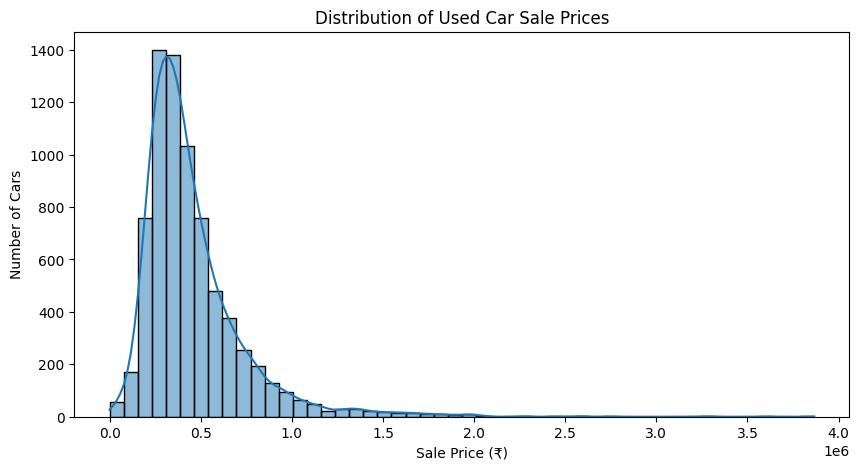

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["sale_price"],kde=True,bins=50)

plt.title("Distribution of Used Car Sale Prices")
plt.xlabel("Sale Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

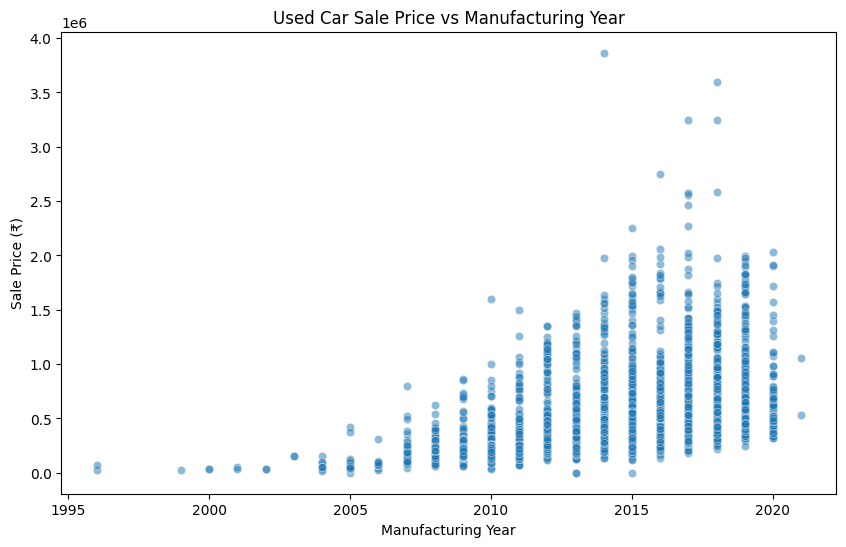

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="yr_mfr",y="sale_price",alpha=0.5)

plt.title("Used Car Sale Price vs Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Sale Price (₹)")

plt.show()

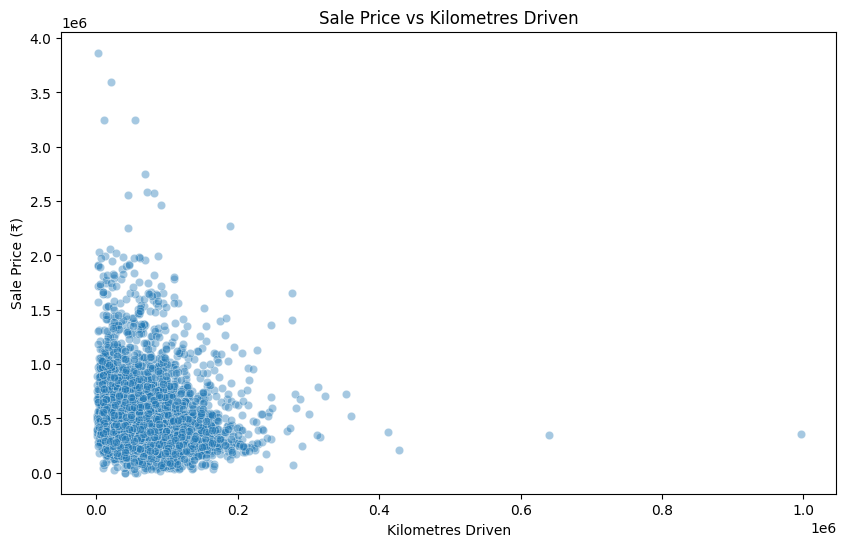

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="kms_run",y="sale_price",alpha=0.4)

plt.title("Sale Price vs Kilometres Driven")
plt.xlabel("Kilometres Driven")
plt.ylabel("Sale Price (₹)")

plt.show()

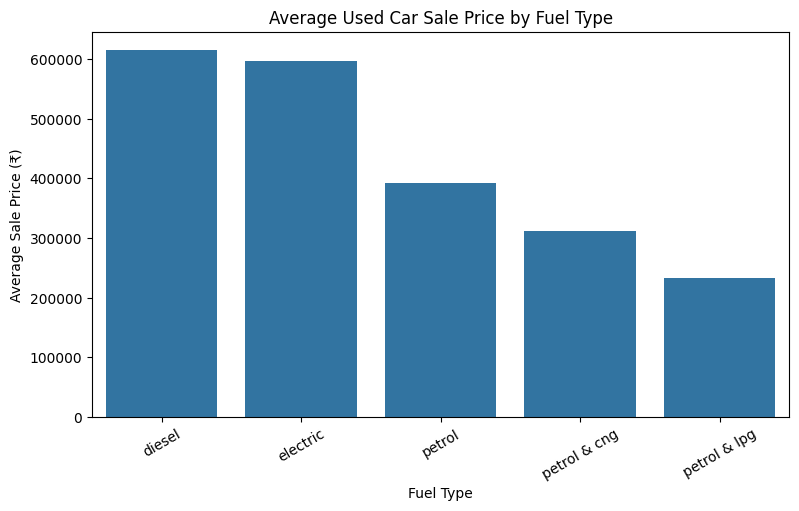

In [12]:
fuel_price = (df.groupby("fuel_type")["sale_price"].mean().sort_values(ascending=False))

plt.figure(figsize=(9, 5))

sns.barplot(x=fuel_price.index,y=fuel_price.values)

plt.title("Average Used Car Sale Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Sale Price (₹)")

plt.xticks(rotation=30)

plt.show()

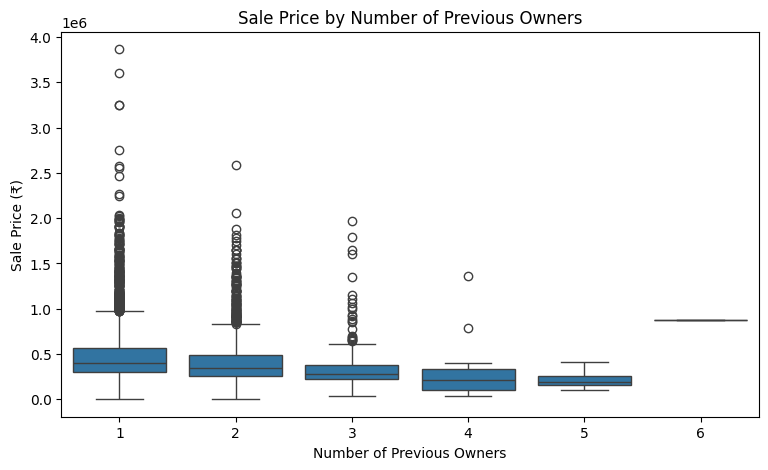

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df,x="total_owners",y="sale_price")

plt.title("Sale Price by Number of Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Sale Price (₹)")

plt.show()

In [14]:
df = df.drop(
    columns=[
        "rto",
        "source",
        "car_availability",
        "ad_created_on",
        "emi_starts_from",
        "booking_down_pymnt",
        "reserved"
    ]
)

In [15]:
X = df.drop("sale_price", axis=1)
y = df["sale_price"]

In [16]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(include=["object", "bool"]).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['yr_mfr', 'kms_run', 'times_viewed', 'total_owners', 'broker_quote', 'original_price']

Categorical columns:
['car_name', 'fuel_type', 'city', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'make', 'model', 'car_rating', 'fitness_certificate', 'warranty_avail']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [18]:
numeric_imputer = SimpleImputer(strategy="median")

X_train_numeric = numeric_imputer.fit_transform(X_train[numeric_columns])
X_test_numeric = numeric_imputer.transform(X_test[numeric_columns])

In [19]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_categorical = categorical_imputer.fit_transform(X_train[categorical_columns])
X_test_categorical = categorical_imputer.transform(X_test[categorical_columns])

In [20]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

X_train_categorical = encoder.fit_transform(X_train_categorical)
X_test_categorical = encoder.transform(X_test_categorical)

In [21]:
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(X_train_numeric)
X_test_numeric = scaler.transform(X_test_numeric)

In [22]:
X_train_processed = np.hstack([X_train_numeric,X_train_categorical])
X_test_processed = np.hstack([X_test_numeric,X_test_categorical])

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (5919, 1508)
Testing shape: (1480, 1508)


In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed,y_train)
lr_pred = lr_model.predict(X_test_processed)

In [24]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression--")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 score:", lr_r2)

Linear Regression--
MAE: 26157.171931479992
RMSE: 86589.15226437902
R2 score: 0.9168498080058098


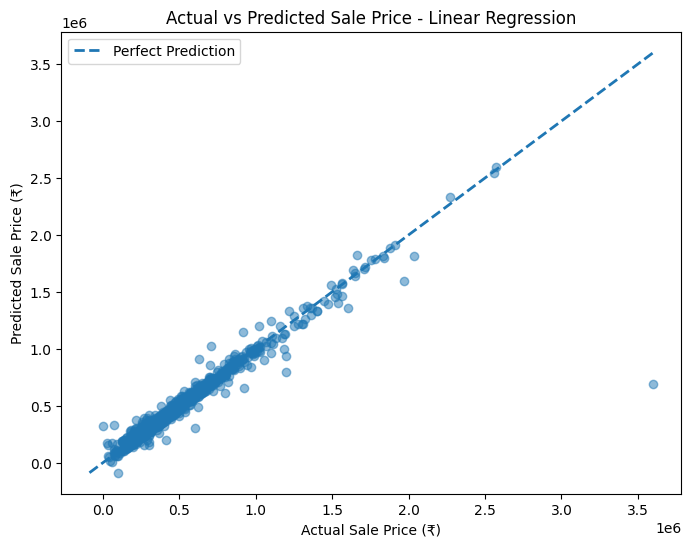

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test,lr_pred,alpha=0.5)

min_value = min(y_test.min(), lr_pred.min())
max_value = max(y_test.max(), lr_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sale Price - Linear Regression")
plt.xlabel("Actual Sale Price (₹)")
plt.ylabel("Predicted Sale Price (₹)")
plt.legend()

plt.show()

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed,y_train)
rf_pred = rf_model.predict(X_test_processed)

In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest--")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest--
MAE: 18883.844623873872
RMSE: 86717.32767733693
R2: 0.916603456167473


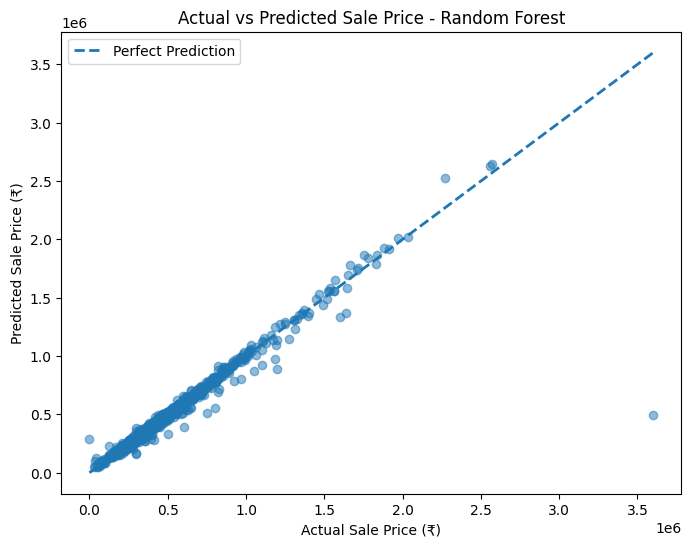

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test,rf_pred,alpha=0.5)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sale Price - Random Forest")
plt.xlabel("Actual Sale Price (₹)")
plt.ylabel("Predicted Sale Price (₹)")
plt.legend()

plt.show()

In [29]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_model.fit(X_train_processed,y_train)
gb_pred = gb_model.predict(X_test_processed)

In [30]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting--")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

Gradient Boosting--
MAE: 18915.290096413028
RMSE: 80672.96715102339
R2: 0.9278240777450113


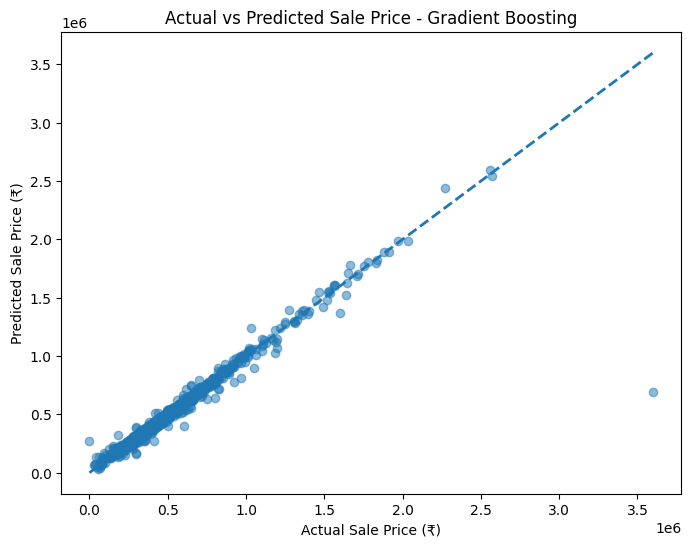

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,gb_pred,alpha=0.5)

min_value = min(y_test.min(), gb_pred.min())
max_value = max(y_test.max(), gb_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Sale Price - Gradient Boosting")
plt.xlabel("Actual Sale Price (₹)")
plt.ylabel("Predicted Sale Price (₹)")
plt.show()

In [32]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [34]:
history = model.fit(
    X_train_processed,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 286541479936.0000 - mae: 455483.0312 - val_loss: 264530329600.0000 - val_mae: 441450.5625
Epoch 2/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 235062263808.0000 - mae: 396405.1250 - val_loss: 141470253056.0000 - val_mae: 284980.0312
Epoch 3/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 82375983104.0000 - mae: 180225.0156 - val_loss: 38727819264.0000 - val_mae: 126248.8672
Epoch 4/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 40442163200.0000 - mae: 125778.6016 - val_loss: 25135355904.0000 - val_mae: 103176.8047
Epoch 5/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 28965840896.0000 - mae: 100534.7969 - val_loss: 16582561792.0000 - val_mae: 79507.5156
Epoch 6/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 21216491520.0000 - mae: 81730.0625 - val_loss: 11521211392.0000 - val_mae: 62560.7109
Epoch 7/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 17499310080.0000 - mae: 71291.6484 - val_lo

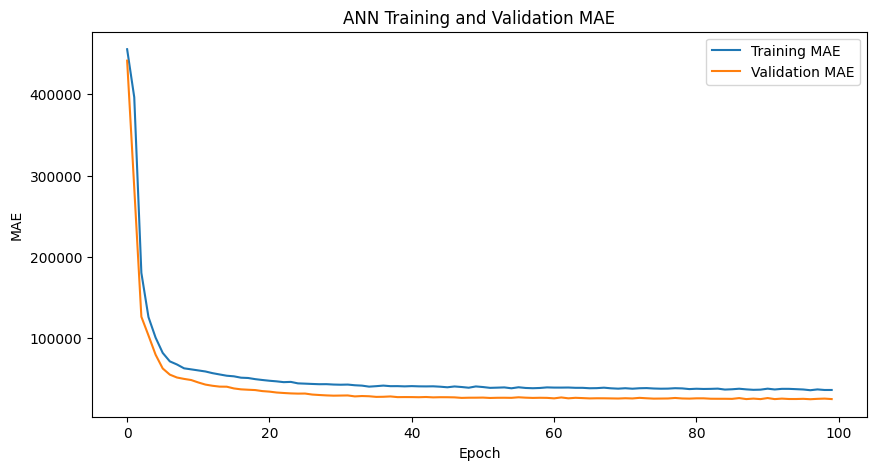

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["mae"],label="Training MAE")

plt.plot(history.history["val_mae"],label="Validation MAE")

plt.title("ANN Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.show()

In [36]:
ann_pred = model.predict(X_test_processed).flatten()

print("First 10 predictions:")
print(ann_pred[:10])

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 10 predictions:
[472109.16 229534.39 492987.72 213984.58 457219.47 226956.27 200465.23
 411802.84 310145.6  358398.62]


In [37]:
ann_mae = mean_absolute_error(y_test,ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test,ann_pred))
ann_r2 = r2_score(y_test,ann_pred)

print("ANN--")
print(f"MAE  : {ann_mae}")
print(f"RMSE : {ann_rmse}")
print(f"R2   : {ann_r2}")

ANN--
MAE  : 25371.51953125
RMSE : 85470.53836264284
R2   : 0.9189842939376831


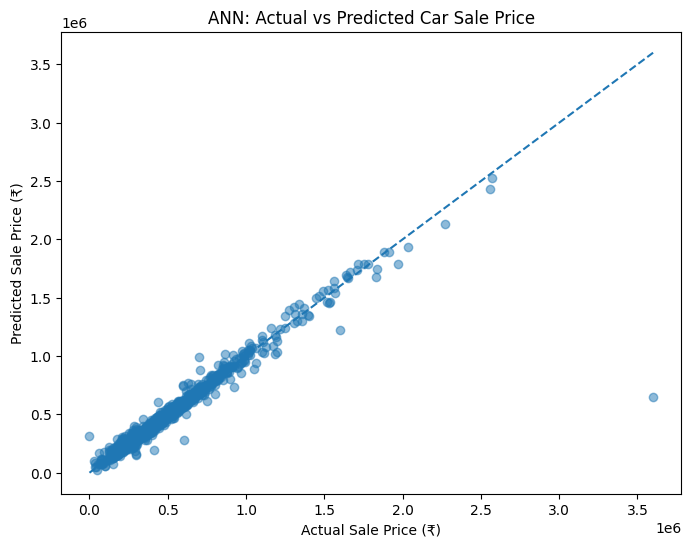

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test,ann_pred,alpha=0.5)

min_value = min(y_test.min(),ann_pred.min())

max_value = max(y_test.max(),ann_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("ANN: Actual vs Predicted Car Sale Price")

plt.xlabel("Actual Sale Price (₹)")
plt.ylabel("Predicted Sale Price (₹)")

plt.show()

In [39]:
# MODEL COMPARISON

results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","Gradient Boosting","ANN"],

    "MAE": [lr_mae,rf_mae,gb_mae,ann_mae],

    "RMSE": [lr_rmse,rf_rmse,gb_rmse,ann_rmse],

    "R2 Score": [lr_r2,rf_r2,gb_r2,ann_r2]
})

# Sorting by R2 score
results = results.sort_values(by="R2 Score",ascending=False).reset_index(drop=True)

print("Model Comparison:")
display(results)

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,18915.290096,80672.967151,0.927824
1,ANN,25371.519531,85470.538363,0.918984
2,Linear Regression,26157.171931,86589.152264,0.916850
3,Random Forest,18883.844624,86717.327677,0.916603


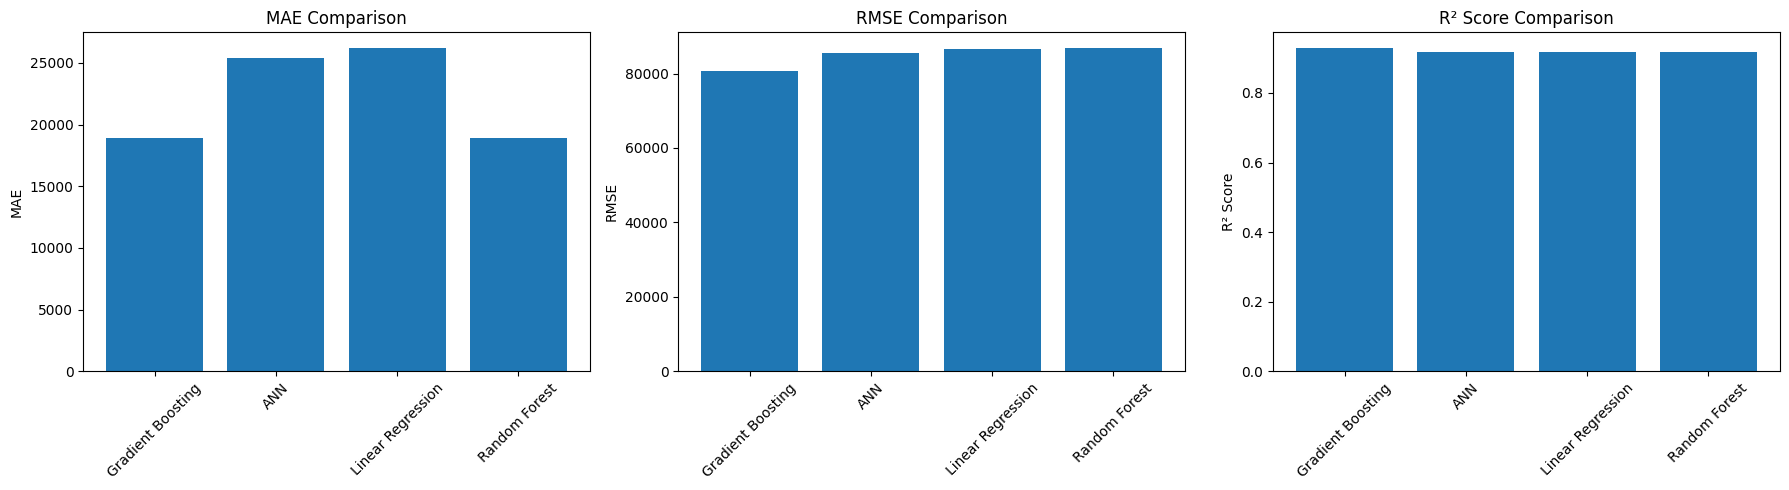

In [40]:
# VISUAL COMPARISON

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(results["Model"], results["MAE"])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

# RMSE
axes[1].bar(results["Model"], results["RMSE"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# R2 Score
axes[2].bar(results["Model"], results["R2 Score"])
axes[2].set_title("R² Score Comparison")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

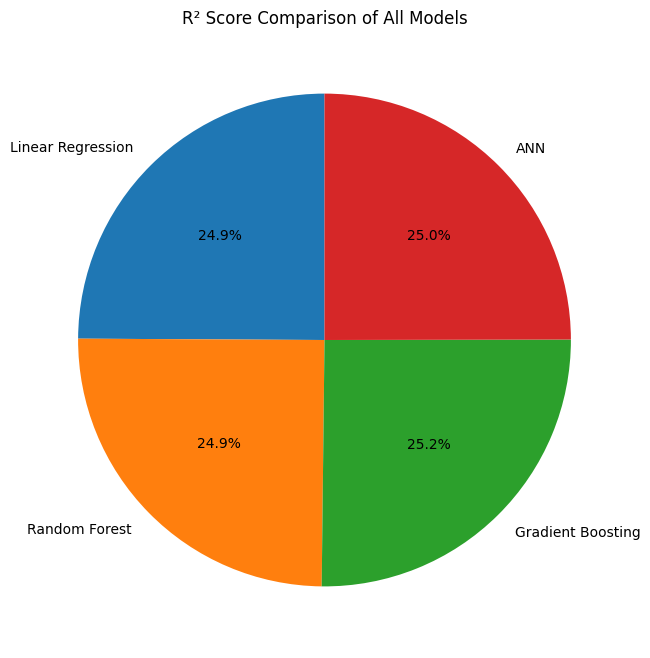

In [41]:
models = ["Linear Regression","Random Forest","Gradient Boosting","ANN"]

r2_scores = [lr_r2,rf_r2,gb_r2,ann_r2]

plt.figure(figsize=(8, 8))

plt.pie(
    r2_scores,
    labels=models,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("R² Score Comparison of All Models")

plt.show()

In [42]:
# SELECTING THE BEST MODEL

best_model_name = results.loc[0, "Model"]

best_mae = results.loc[0, "MAE"]
best_rmse = results.loc[0, "RMSE"]
best_r2 = results.loc[0, "R2 Score"]

print("   BEST MODEL SELECTION--")

print(f"Best Model : {best_model_name}")
print(f"MAE        : {best_mae:.2f}")
print(f"RMSE       : {best_rmse:.2f}")
print(f"R² Score   : {best_r2:.4f}")

   BEST MODEL SELECTION--
Best Model : Gradient Boosting
MAE        : 18915.29
RMSE       : 80672.97
R² Score   : 0.9278


In [46]:
# Testing with new input - GRADIENT BOOSTING

user_input = {
    "car_name": input("Car Name: ").strip().lower(),
    "yr_mfr": int(input("Manufacturing Year: ")),
    "fuel_type": input("Fuel Type: ").strip().lower(),
    "kms_run": float(input("Kilometers Driven: ")),
    "city": input("City: ").strip().lower(),
    "times_viewed": int(input("Times Viewed: ")),
    "body_type": input("Body Type: ").strip().lower(),
    "transmission": input("Transmission: ").strip().lower(),
    "variant": input("Variant: ").strip().lower(),
    "assured_buy": input("Assured Buy (True/False): ").strip().lower() == "true",
    "registered_city": input("Registered City: ").strip().lower(),
    "registered_state": input("Registered State: ").strip().lower(),
    "is_hot": input("Is Hot (True/False): ").strip().lower() == "true",
    "make": input("Manufacturer: ").strip().lower(),
    "model": input("Model: ").strip().lower(),
    "total_owners": int(input("Total Owners: ")),
    "broker_quote": float(input("Broker Quote (₹): ")),
    "original_price": float(input("Original Price (₹): ")),
    "car_rating": input("Car Rating: ").strip().lower(),
    "fitness_certificate": input(
        "Fitness Certificate (True/False): "
    ).strip().lower() == "true",
    "warranty_avail": input(
        "Warranty Available (True/False): "
    ).strip().lower() == "true"
}
new_car = pd.DataFrame([user_input])

X_num = numeric_imputer.transform(new_car[numeric_columns])
X_num = scaler.transform(X_num)
X_cat = categorical_imputer.transform(new_car[categorical_columns])
X_cat = encoder.transform(X_cat)
X_new = np.hstack([X_num, X_cat])

predicted_price = gb_model.predict(X_new)[0]
print("\n")
print(f"    Estimated Resale Price: ₹{predicted_price:,.2f}")

Car Name: maruti swift
Manufacturing Year: 2018
Fuel Type: petrol
Kilometers Driven: 35000
City: mumbai
Times Viewed: 1200
Body Type: hatchback
Transmission: manual
Variant: vxi
Assured Buy (True/False): true
Registered City: mumbai
Registered State: maharashtra
Is Hot (True/False): false
Manufacturer: maruti
Model: swift
Total Owners: 1
Broker Quote (₹): 450000
Original Price (₹): 600000
Car Rating: great
Fitness Certificate (True/False): true
Warranty Available (True/False): false


    Estimated Resale Price: ₹478,853.38
